## STOCHASTIC MODELING
MODULE 1 | LESSON 3


---


# **JUMP DIFFUSION MODELS**


|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** | Black-Scholes, Heston, Stochastic volatility |
|**Keywords** | Merton, Jumps |


---


In the previous lessons we dealt with **stochastic volatility** models, which helped us bridge the gap between the strong assumptions of the Black-Scholes world and empirical stylized facts of stock returns.

In this lesson, we look at another important characteristic that asset prices exhibit in real life: **jumps**.

## **1. Jump-Diffusion Models**

When we began working on continuous time, we started with a **normally distributed world** with **constant volatility** (e.g., Black-Scholes). Then, we transitioned to one in which **volatility is non-constant** (e.g., CEV) and even is **stochastic** (e.g., Heston). Our focus so far has been primarily on the volatility part of the underlying price process. Let's now turn to the **drift component**.

The GBM model (even in Heston) produces an arguably "smooth" stock price evolution, where changes in stock prices ($dS$) had a distinctive trend (i.e., drift)

However, this is not really (or, at least, not always) what happens in reality, where prices constantly experience **jumps**. For instance, due to good (e.g., earnings surprise) or bad (e.g., profit warning) news arriving to the market.

These jumps happen more regularly than one might think, and they  can even extend to the whole market. See, below, the evolution of S\&P500 index from 2024 to  July 2025:


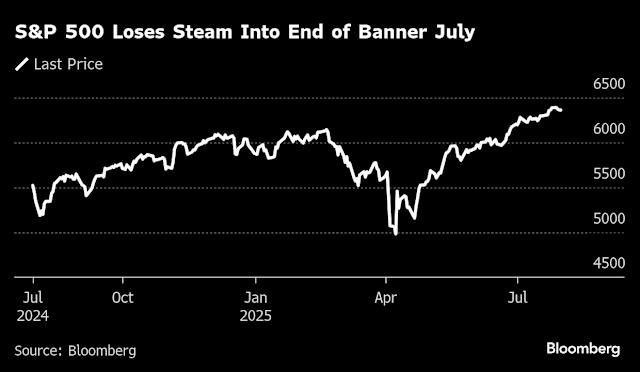

This is precisely the kind of stylized fact that Merton (1976) model incorporates. Here you have a price path simulated under classic GBM (left) and Merton (1976) jump-diffusion model (right):

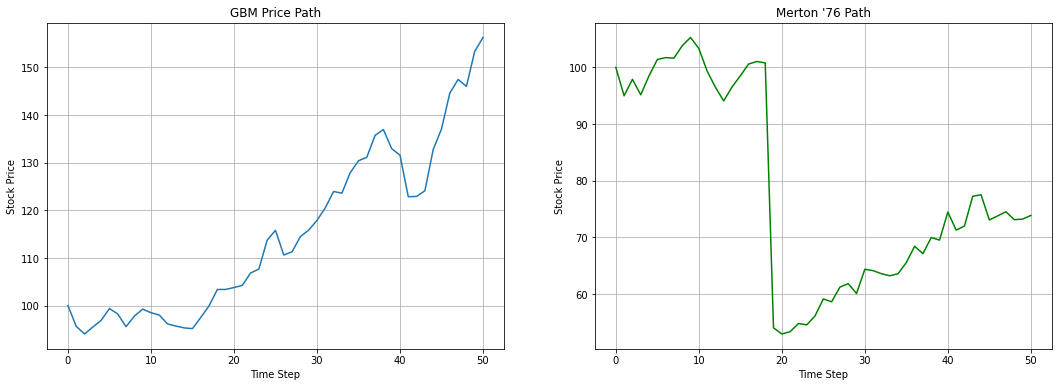

## **2. Merton (1976) model**

One of the most famous jump diffusion models for option pricing is the **Merton (1976)** model. Here's the original paper reference:

*Merton, Robert C. "Option pricing when underlying stock returns are discontinuous.", Journal of Financial Economics, vol. 3, no. 1–2, 1976, pp. 125–144.*

Merton's '76 model SDE includes both a Brownian motion and a Poisson jump process with intensity $\lambda$ and average jump size $\mu_j$:

$$
    dS_t = \left( r - r_j \right) S_t dt + \sigma S_t dZ_t + J_t S_t dN_t
$$

where,

- $r_j = \lambda \left(e^{\mu_j+\frac{\delta^2}{2}}-1\right)$

  is the "correction" to the drift term in order to maintain the risk-neutral measure.

- $J_t$ is a jump at time $t$, which follows the distribution:
$$
Log(1+J_t) \approx Normal\left( log(1+\mu_j)-\frac{\delta^2}{2}, \ \delta^2 \right)
$$


\
Similar to what we have done with other previous models, we can use Monte Carlo methods on the discretized version of the model for pricing:

\
$$
S_t = S_{t-1} \left( e^{\left(r-r_j-\frac{\sigma^2}{2}\right)dt + \sigma \sqrt{dt} z_t^1}+\left(e^{\mu_j+\delta z_t^2}-1 \right) y_t \right)
$$

\
Note that we have **3 sources of randomness** here:

1. Stock price diffusion (standard normal): $z_t^1$

2. Size of the jump (standard normal): $z_t^2$

3. Timing of the jump (Poisson): $y_t$

\
Also, note the importance of variables $\mu_j$ and $\lambda$, the average size and intensity (frequency) of the jump:

- How to assess these parameters? $\rightarrow$ **Calibration**

- In the next lesson, we will learn to implement the model in Python and play around with these.

## **3. Poisson processes**

Merton (1976) models stock price jumps in a very convenient way using random processes following a **Poisson distribution**.

\
If you are familiar with Poisson distributions, this should not surprise you, as it is a process often used to model the **occurrence of events**. Some applications are:


- Traffic flow $\rightarrow$ theory of queues, how long should I wait for the bus?

- Firm bankruptcy  $\rightarrow$ assess the probability of default.

- Insurance claims $\rightarrow$ probability of reporting an accident \& assessment of insurance premium.

\
The probability mass function of a Poisson-distributed random variable $X$ is defined as:

\
$$
    P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}
$$

\
where $k$ is the number of occurrences of the event, and $\lambda>0$.
Also, note that:

$$
\lambda = E(X) = Var(X)
$$

## **4. When do we use each model?**

Before we turn to empirically implementing the Merton '76 model, you may  be wondering how we can select the best possible model to use. The answer to this is not straightforward, and depends on a number of different issues that we will develop on in subsequent modules. Here you have a quick reflection on these that can serve as appetizer:

In [1]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1116720138", h="3298dbabb7", width=700, height=450)

## **5. Conclusion**

Now that we know the basics about Merton (1976) and the incorporation of jumps into our models, let's practice with them!

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.